2.3. Simule el comportamiento de un robot con tres sensores de distancia, que recorre un espacio
bidimensional, donde hay 4 objetos distribuidos aleatoriamente, que no se choca con esos objetos.

## Estructura y Componentes Clave

### Robot:
  * **`posición (x, y)`**: Coordenadas actuales en el mapa.
  * **`dirección (ángulo)`**: Orientación del robot, que determina su movimiento y la dirección de sus sensores.
  * **`sensores (3 ángulos relativos)`**: Sensores frontales, izquierdo y derecho para detectar distancias a obstáculos y bordes.

### Objetos:
  * **`lista de posiciones aleatorias`**: Obstáculos estáticos distribuidos aleatoriamente en el mapa.

### Bucle principal de simulación:
   
    mientras simulación activa:
        medir sensores
        decidir movimiento
        actualizar posición
        dibujar escena
        repetir


In [43]:
import matplotlib.pyplot as plt
#Para dar colores facilmente a los elementos del mapa
from matplotlib.colors import ListedColormap
import numpy as np
import random

# Definir colores del mapa, obstaculos y bot
cmap = ListedColormap(['white', 'green', 'black'])

In [48]:
# ----- Parámetros -----
SIZE = 25              # Tamaño del mapa
OBJETOS = 80            # Cantidad de Obstaculos
PASOS = 100             # cantidad de pasos

# Estados del mapa
VACIO = 0
OBJETO = 1
ROBOT = 2

### Función `crear_mapa`
Crea un mapa bidimensional con obstáculos distribuidos aleatoriamente.

    Args:
        size (int): El tamaño del lado del mapa (el mapa será size x size).
        objetos (int): La cantidad de obstáculos a colocar en el mapa.

    Returns:
        np.ndarray: Una matriz NumPy que representa el mapa, donde 0 es vacío y 1 es objeto.

In [49]:
def crear_mapa(size, objetos):
    mapa = np.zeros((size, size), dtype=int)
    for _ in range(objetos):
        # Asegurarse de que el objeto no se coloque fuera de los límites
        x, y = random.randint(0, size - 1), random.randint(0, size - 1)
        mapa[x, y] = OBJETO
    return mapa

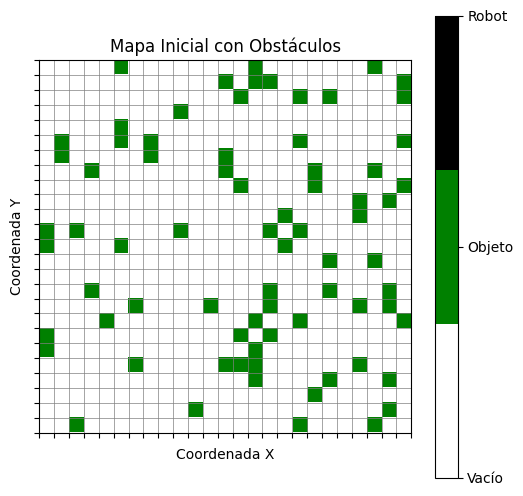

In [50]:
# Visualizar el mapa recién creado
initial_map = crear_mapa(SIZE, OBJETOS)
plt.figure(figsize=(6, 6))
plt.imshow(initial_map, cmap=cmap, vmin=0, vmax=2)
plt.title('Mapa Inicial con Obstáculos')
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.colorbar(ticks=[VACIO, OBJETO, ROBOT], label='', format=plt.FuncFormatter(lambda x, p: {VACIO: 'Vacío', OBJETO: 'Objeto', ROBOT: 'Robot'}.get(x, '')))
plt.grid(True, which='both', color='gray', linestyle='-', linewidth=0.5)
plt.xticks(np.arange(-0.5, SIZE, 1), labels=[])
plt.yticks(np.arange(-0.5, SIZE, 1), labels=[])
plt.show()

### Función `sensor_distancia`
Simula un sensor de distancia desde una posición (x, y) en una dirección (dx, dy).

Calcula la distancia al primer obstáculo o al borde del mapa en la dirección especificada.

    Args:
        mapa (np.ndarray): El mapa bidimensional.
        x (int): Coordenada X actual del sensor.
        y (int): Coordenada Y actual del sensor.
        dx (int): Componente X de la dirección del sensor.
        dy (int): Componente Y de la dirección del sensor.

    Returns:
        int: La distancia hasta el primer obstáculo o el borde del mapa.
    

In [51]:
def sensor_distancia(mapa, x, y, dx, dy):
    distancia = 0
    # Recorrer el mapa en la dirección especificada hasta encontrar un obstáculo o el borde
    while 0 <= x + dx < SIZE and 0 <= y + dy < SIZE:
        x += dx
        y += dy
        distancia += 1
        if mapa[x, y] == OBJETO:
            break # Se encontró un objeto, parar
    return distancia

### Función `rotar`
Rota un vector de dirección (dx, dy) por un ángulo específico (90, -90, 180 grados).

    Args:
        direccion (tuple): Un par (dx, dy) que representa el vector de dirección actual.
        angulo (int): El ángulo de rotación en grados (90, -90, 180).

    Returns:
        tuple: El nuevo vector de dirección (dx_nuevo, dy_nuevo) después de la rotación.

In [52]:
def rotar(direccion, angulo):
    dx, dy = direccion
    if angulo == 90:
        return dy, -dx  # Rotación 90 grados en sentido horario
    elif angulo == -90:
        return -dy, dx # Rotación 90 grados en sentido anti-horario
    elif angulo == 180 or angulo == -180:
        return -dx, -dy # Rotación 180 grados
    return dx, dy # Si el ángulo no es reconocido, no hay rotación

### Función `simular_robot`

Esta es la función principal que orquesta toda la simulación. Se encarga de:

1.  **Inicializar** el mapa y la posición/dirección del robot.
2.  En cada `paso` de la simulación:
    *   **Medir** las distancias a los obstáculos y bordes utilizando los sensores.
    *   **Decidir** la acción a tomar (girar o seguir recto) basándose en las lecturas de los sensores, priorizando la evasión de obstáculos y bordes.
    *   **Actualizar** la posición del robot.
    *   **Visualizar** el estado actual del mapa, el robot, los sensores y la trayectoria, con una animación fluida.

In [53]:
def simular_robot():
    mapa = crear_mapa(SIZE, OBJETOS)
    x, y = SIZE // 2, SIZE // 2  # Posición inicial del robot en el centro del mapa
    direccion = (0, 1)  # Dirección inicial: hacia la derecha (cambiado de (0, 1) a (1, 0) para "derecha" si X es horizontal, Y vertical)

    plt.figure(figsize=(6, 6))

    # Ciclos de los pasos de la simulación
    for paso in range(PASOS):
        mapa_temp = mapa.copy()
        mapa_temp[x, y] = ROBOT  # Colocar el robot en el mapa temporal para visualización

        # --- Lectura de Sensores ---
        # Direcciones de los sensores (relativas a la dirección actual del robot)
        dir_izquierda = rotar(direccion, 90) # Suponiendo rotación 90 es izquierda, -90 es derecha para una perspectiva 'desde arriba'
        dir_frente = direccion
        dir_derecha = rotar(direccion, -90)

        # Leer distancias con los sensores
        dist_izquierda = sensor_distancia(mapa, x, y, *dir_izquierda)
        dist_frente = sensor_distancia(mapa, x, y, *dir_frente)
        dist_derecha = sensor_distancia(mapa, x, y, *dir_derecha)

        # --- Decisión de Movimiento ---
        nueva_direccion = direccion  # Por defecto, el robot intenta seguir recto

        # Si un obstáculo está muy cerca al frente (1 o 2 pasos)
        if dist_frente <= 2:
            # Priorizar girar hacia el lado con más espacio
            if dist_izquierda > dist_derecha:
                nueva_direccion = dir_izquierda  # Girar a la izquierda
            elif dist_derecha > dist_izquierda:
                nueva_direccion = dir_derecha  # Girar a la derecha
            else:
                # Si ambos lados están igual de bloqueados (o libres), girar 90 grados aleatoriamente
                # para intentar salir del apuro. No usamos 180 aquí para evitar movimientos erráticos.
                nueva_direccion = rotar(direccion, 90 if random.random() > 0.5 else -90)

        # --- Ejecución del Movimiento ---
        # Intentar mover el robot en la `nueva_direccion` decidida
        next_dx, next_dy = nueva_direccion
        proposed_x, proposed_y = x + next_dx, y + next_dy

        # Verificar si el movimiento propuesto es válido (dentro de los límites y no hay obstáculo)
        if 0 <= proposed_x < SIZE and 0 <= proposed_y < SIZE and mapa[proposed_x, proposed_y] != OBJETO:
            x, y = proposed_x, proposed_y  # Actualizar posición
            direccion = nueva_direccion      # Actualizar la dirección real del robot
        else:
            # Si el movimiento propuesto no es válido, intentar encontrar una dirección libre girando.
            # Esto maneja situaciones donde el robot está "atrapado" o la primera rotación no fue suficiente.
            # Intentamos hasta 4 giros (90, 180, 270, 0 grados relativos a la nueva_direccion) para buscar un camino.
            movido = False
            for _ in range(4):
                nueva_direccion = rotar(nueva_direccion, 90) # Girar 90 grados a la derecha
                next_dx, next_dy = nueva_direccion
                proposed_x, proposed_y = x + next_dx, y + next_dy

                if 0 <= proposed_x < SIZE and 0 <= proposed_y < SIZE and mapa[proposed_x, proposed_y] != OBJETO:
                    x, y = proposed_x, proposed_y
                    direccion = nueva_direccion
                    movido = True
                    break  # Encontró una dirección y se movió, salir del bucle de giros
            if not movido:
                # Si después de 4 giros aún no se puede mover, el robot se queda quieto
                # y mantiene su última dirección (o podría intentar retroceder en un futuro).
                pass # El robot no se mueve en este paso si no hay camino

        # --- Visualización ---
        plt.clf()  # Limpiar la figura actual
        plt.imshow(mapa_temp, cmap=cmap, vmin=0, vmax=2) # Mostrar el mapa con el robot
        plt.title(f"Paso {paso + 1}")
        plt.grid(True, which='both', color='gray', linestyle='-', linewidth=0.5)
        plt.xticks(np.arange(-0.5, SIZE, 1), labels=[])
        plt.yticks(np.arange(-0.5, SIZE, 1), labels=[])
        plt.pause(0.25)  # Pequeña pausa para la animación

    plt.show()

##Iniciar Simulación

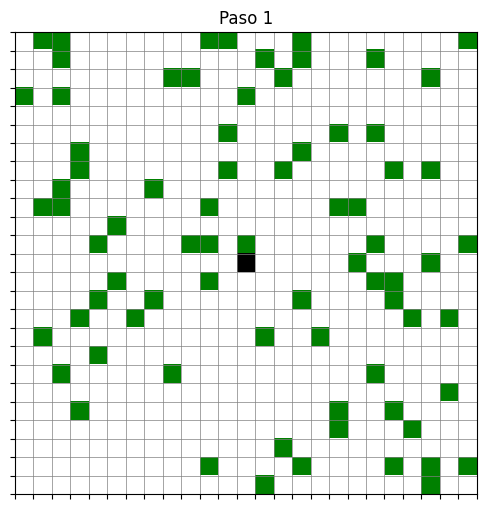

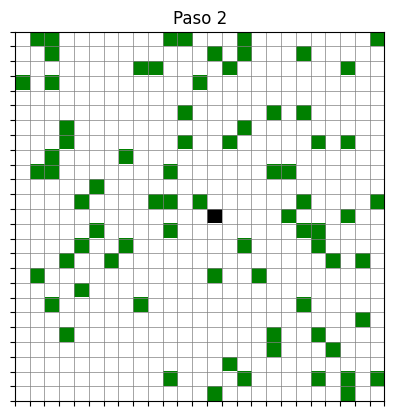

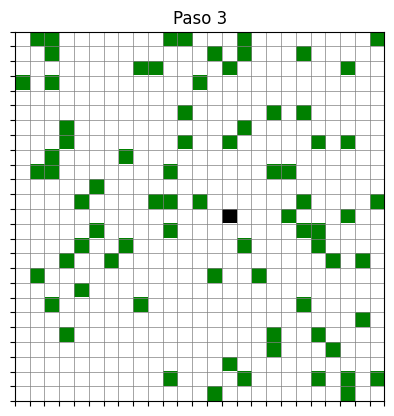

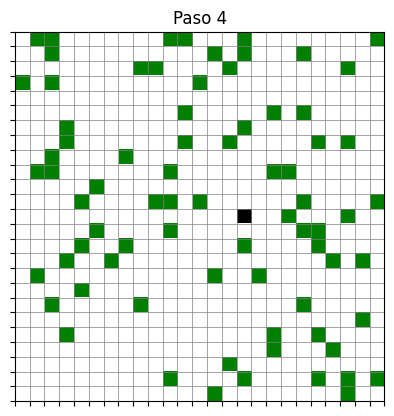

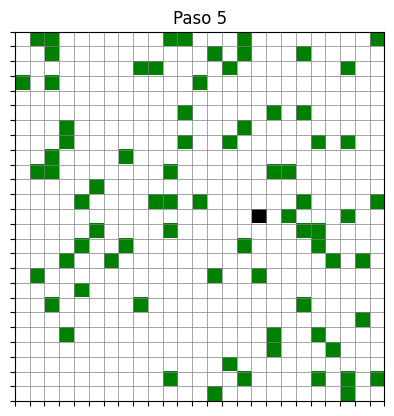

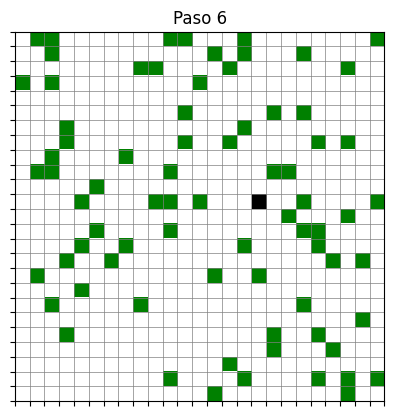

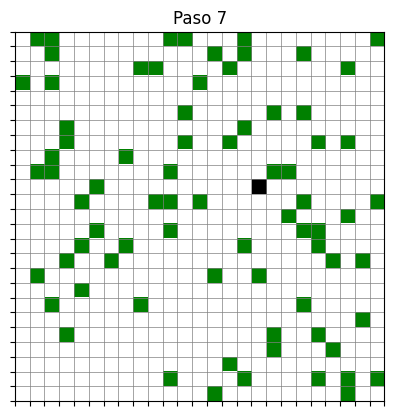

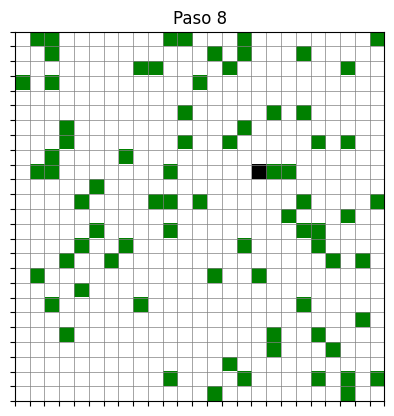

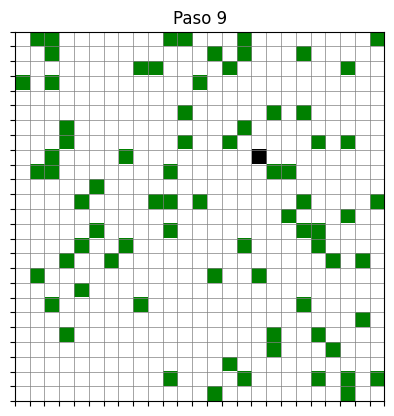

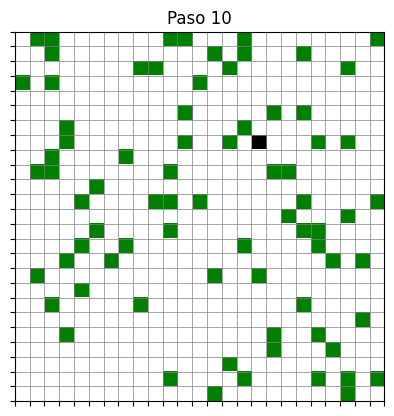

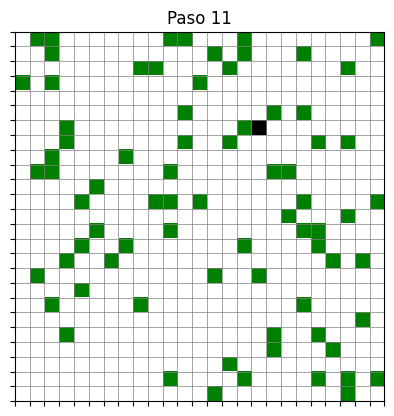

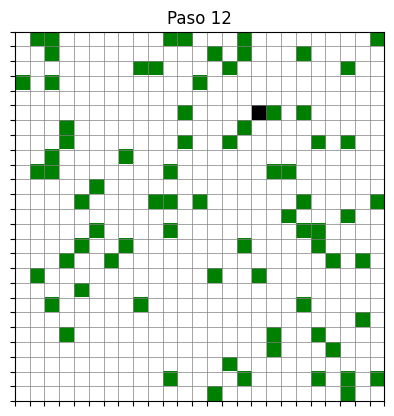

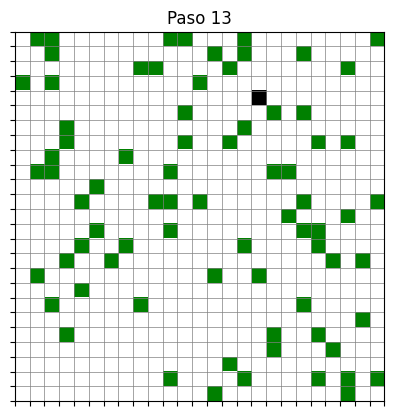

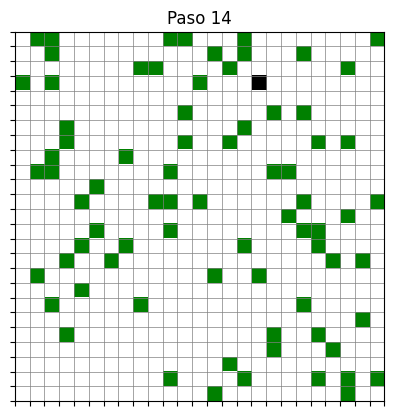

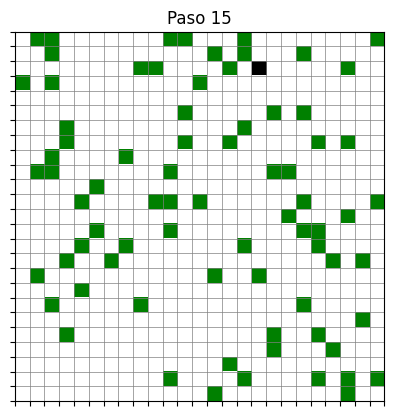

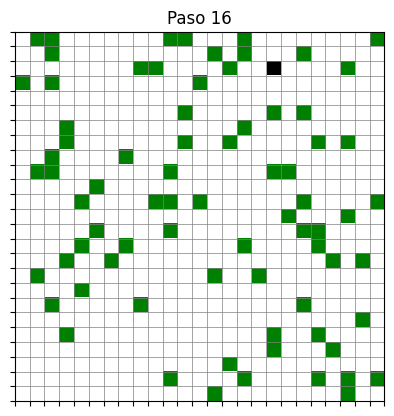

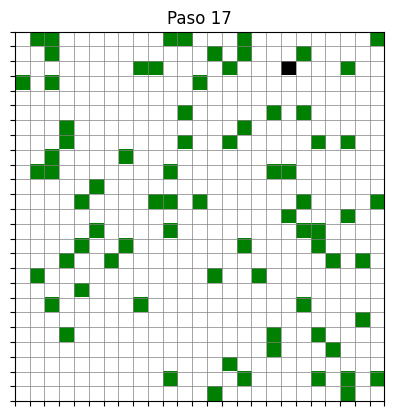

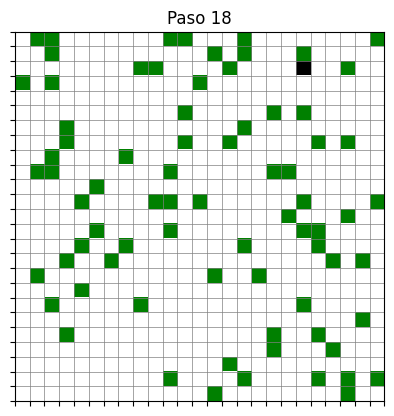

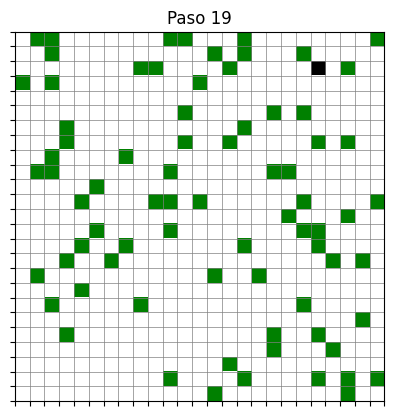

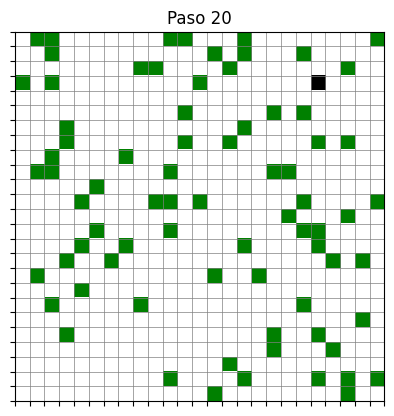

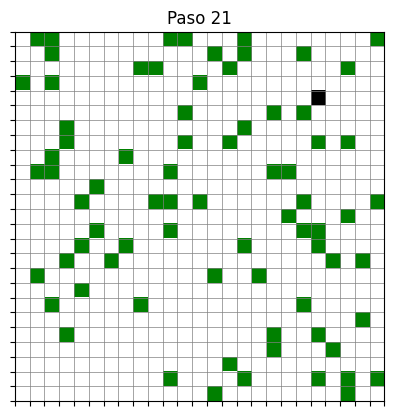

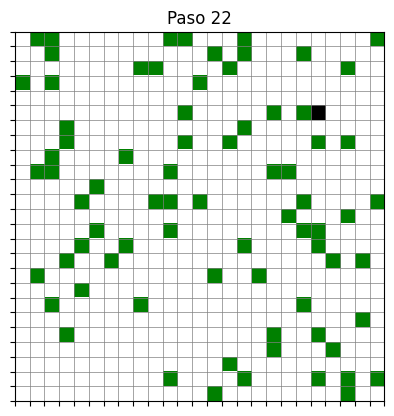

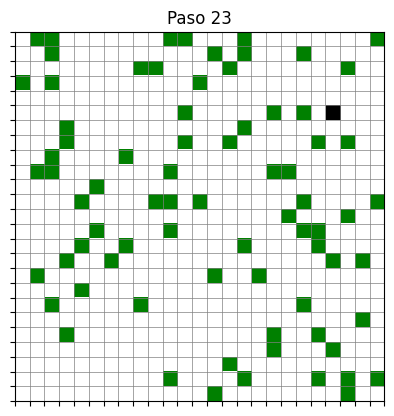

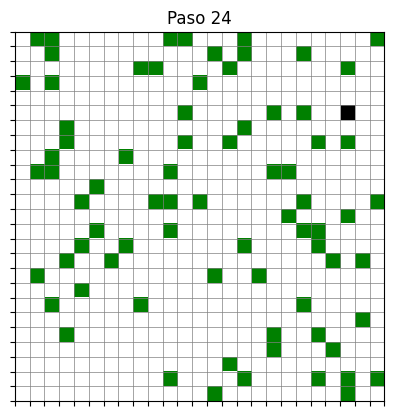

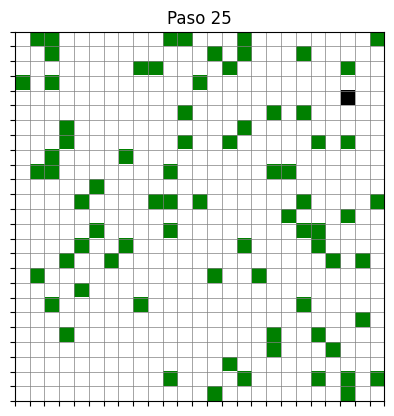

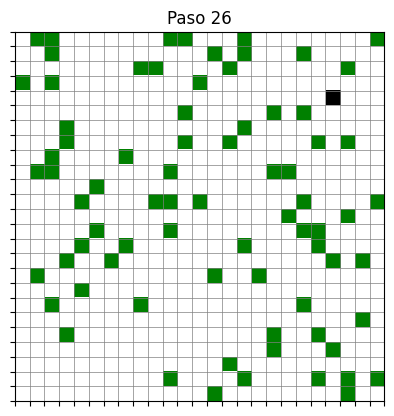

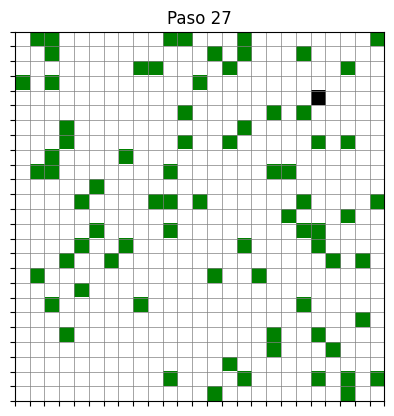

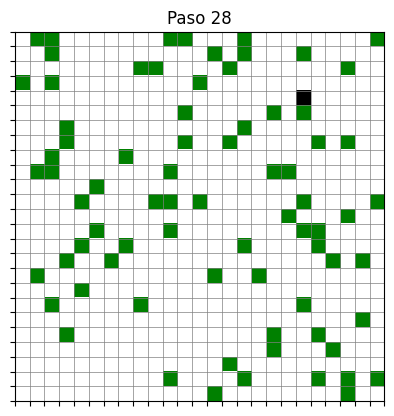

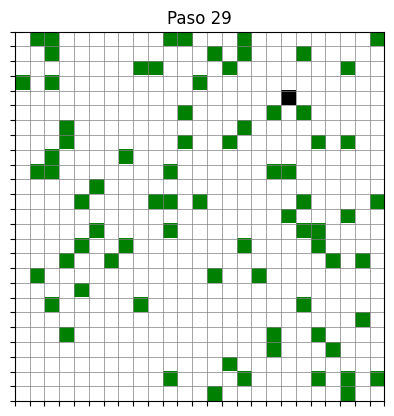

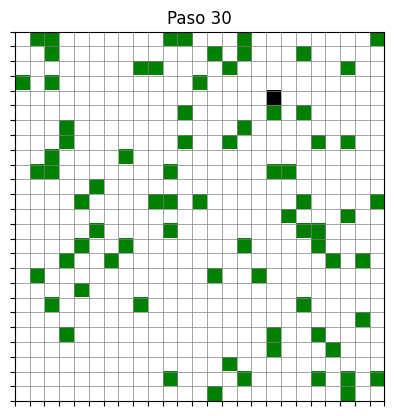

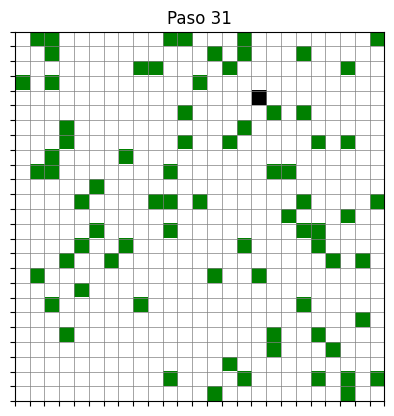

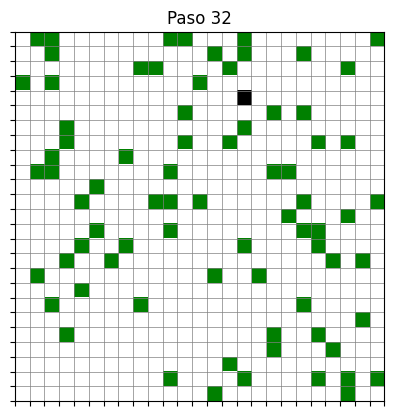

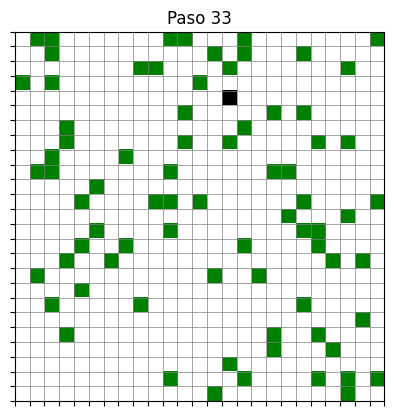

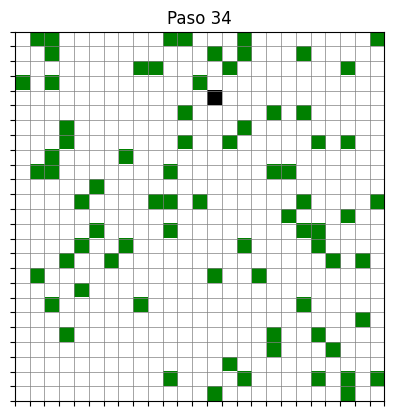

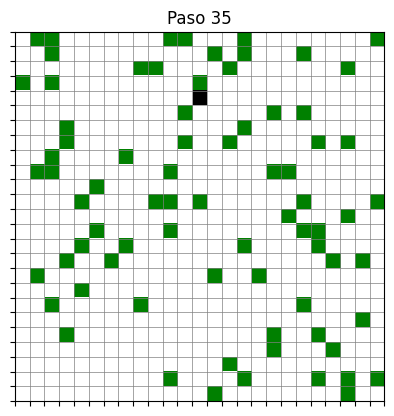

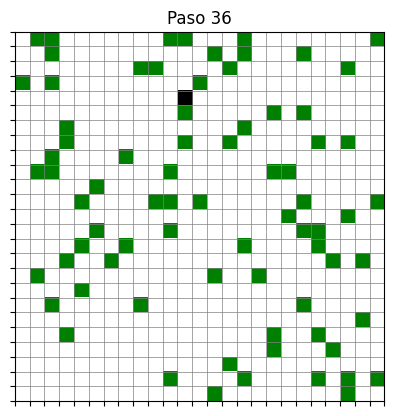

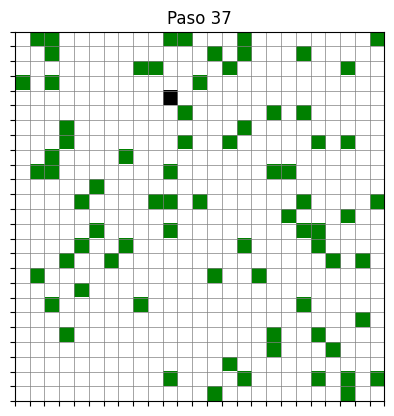

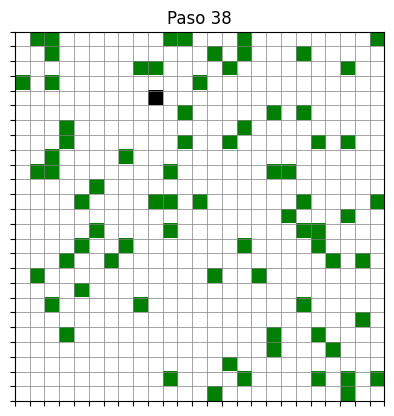

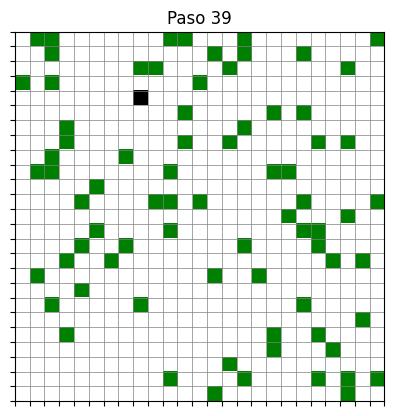

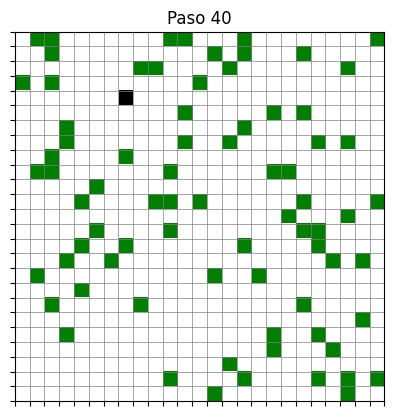

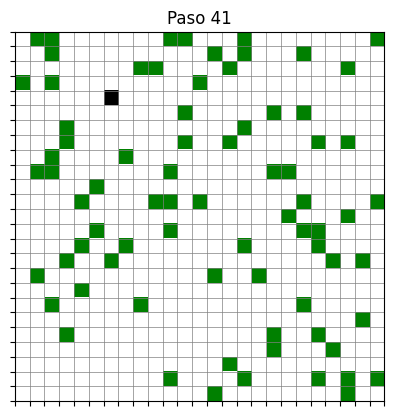

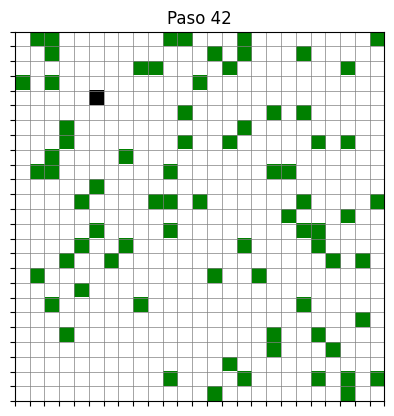

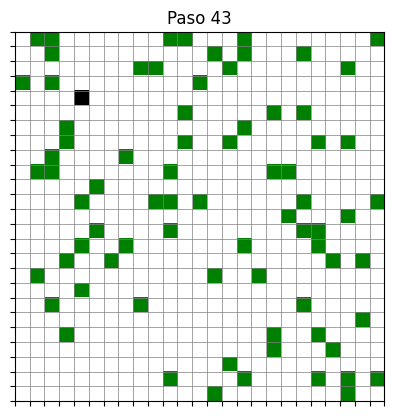

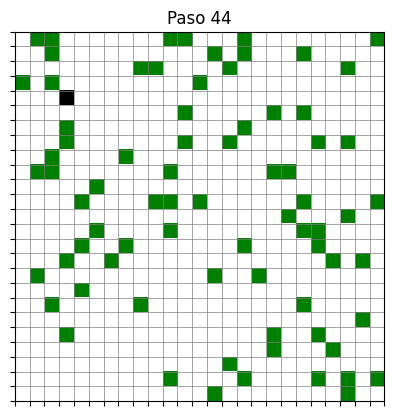

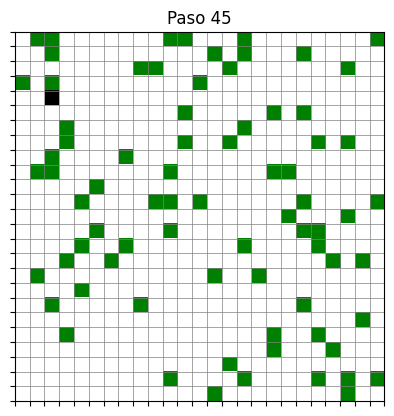

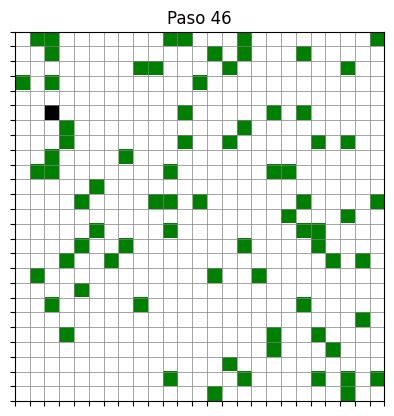

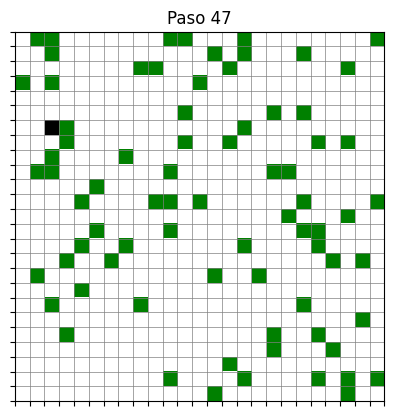

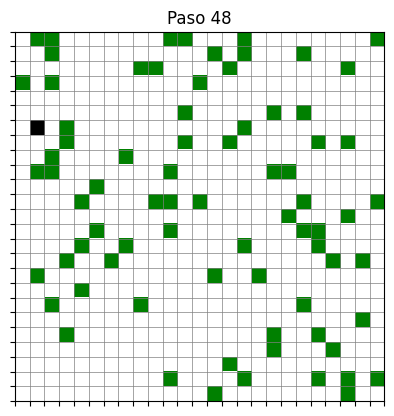

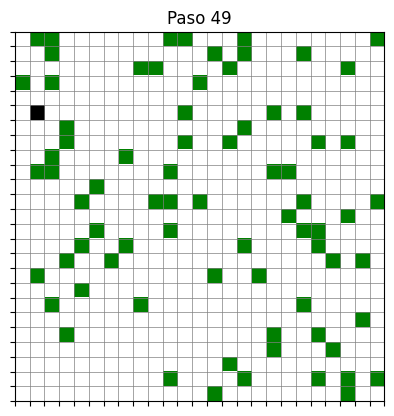

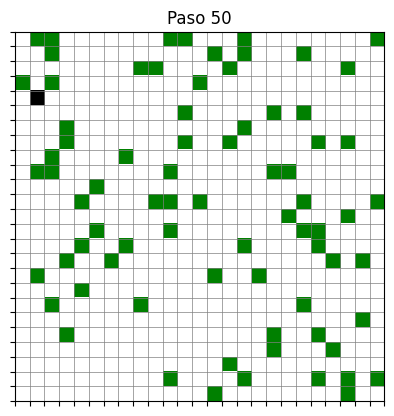

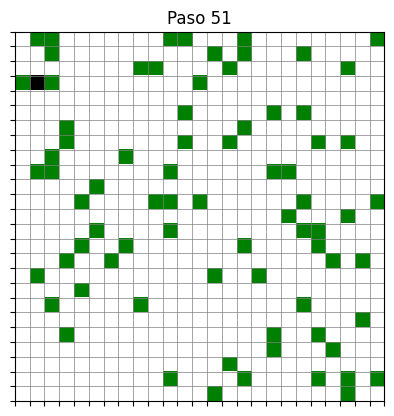

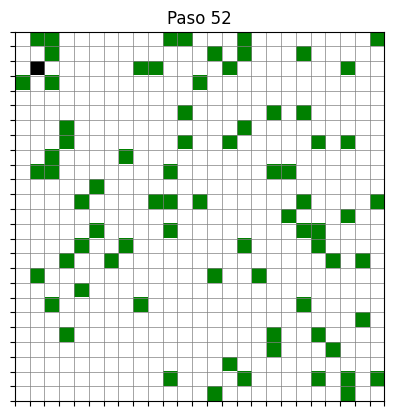

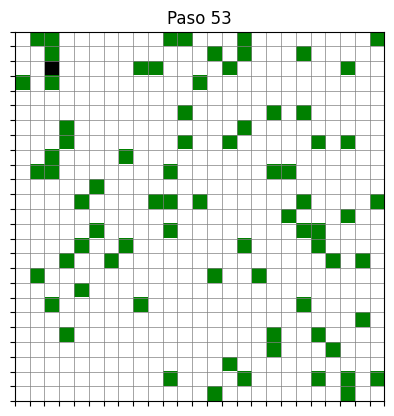

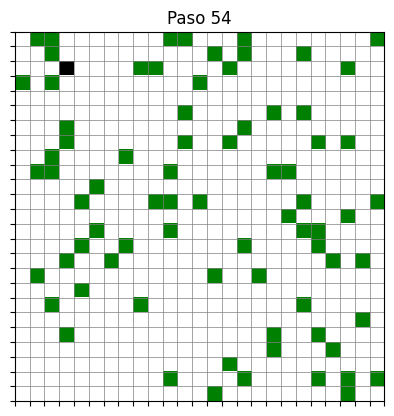

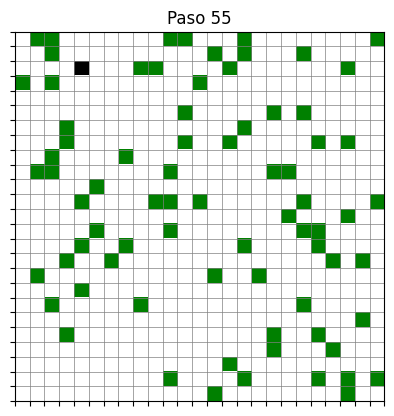

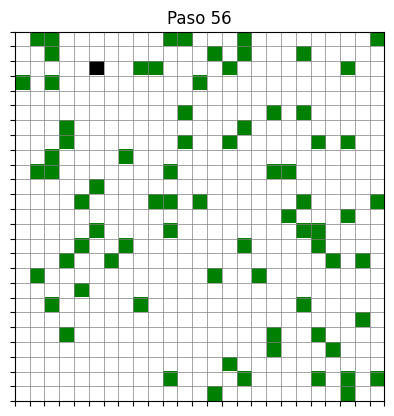

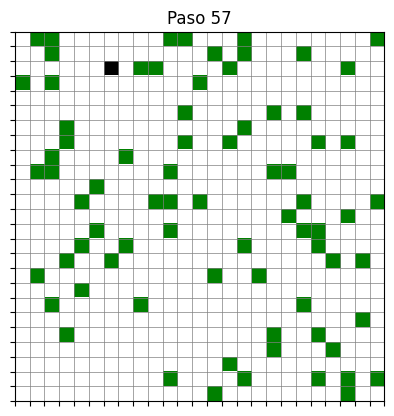

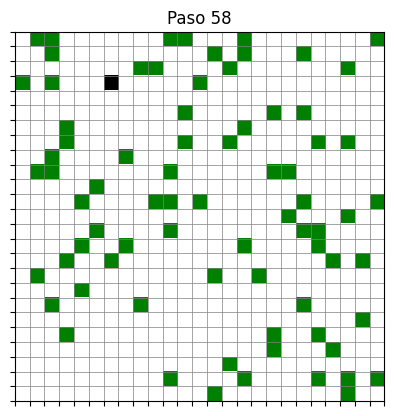

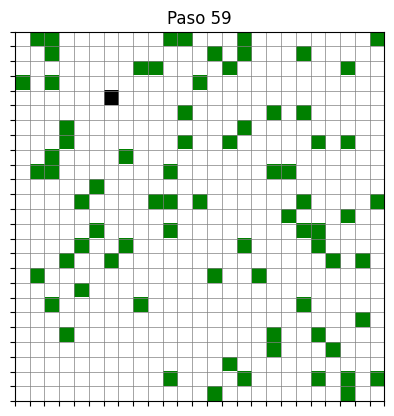

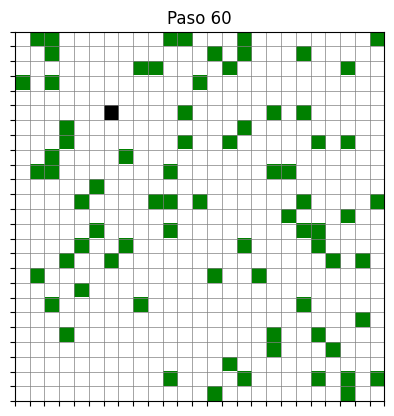

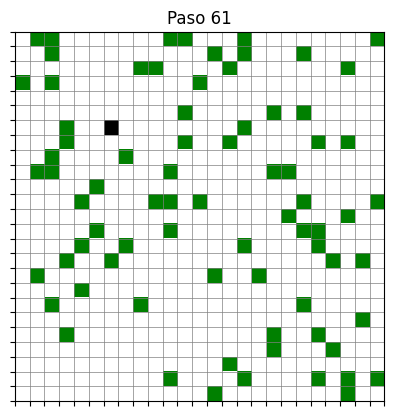

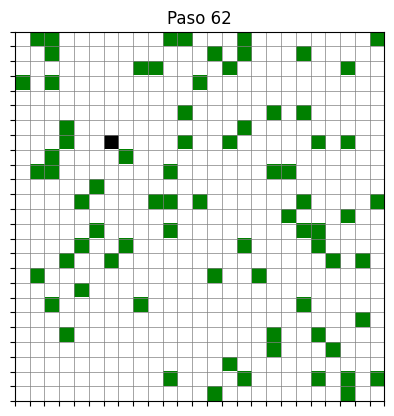

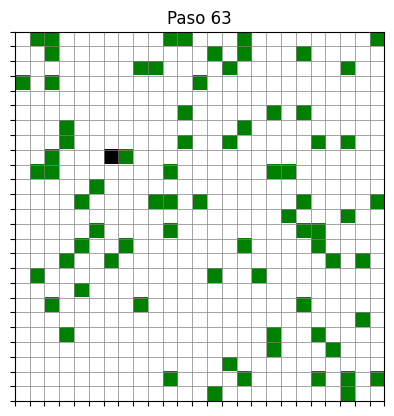

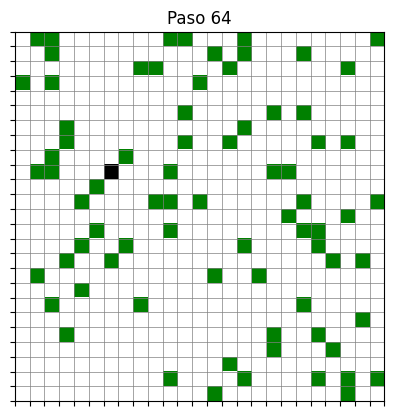

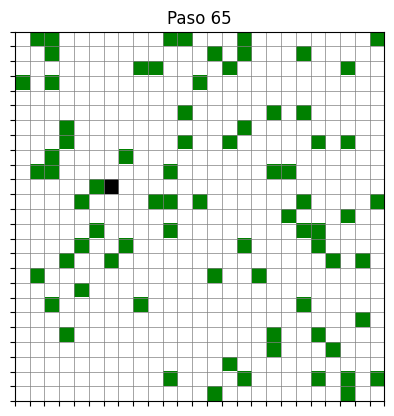

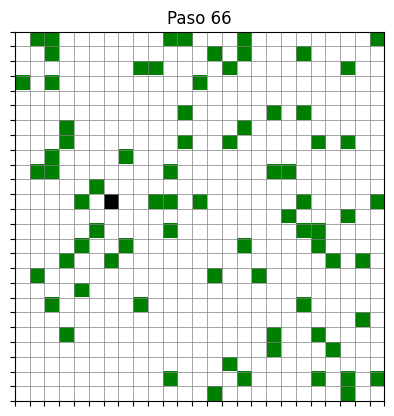

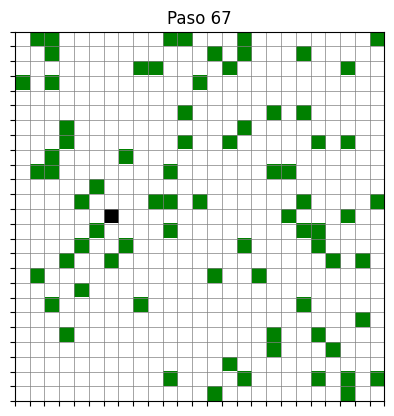

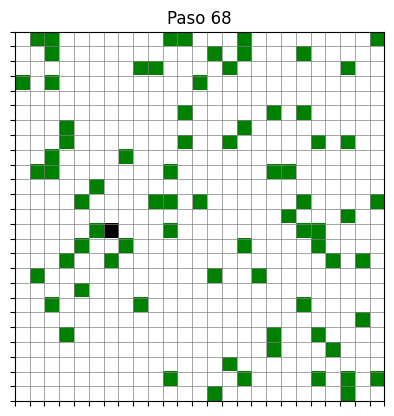

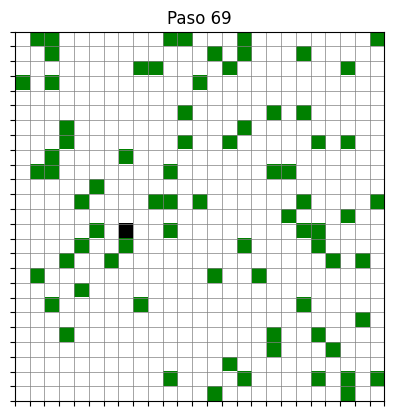

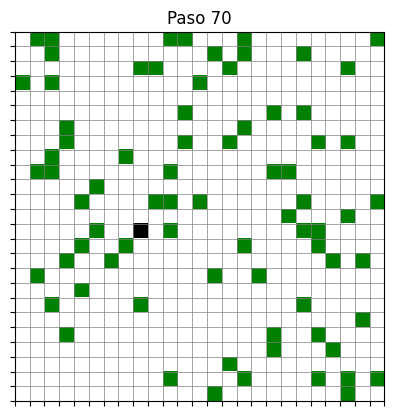

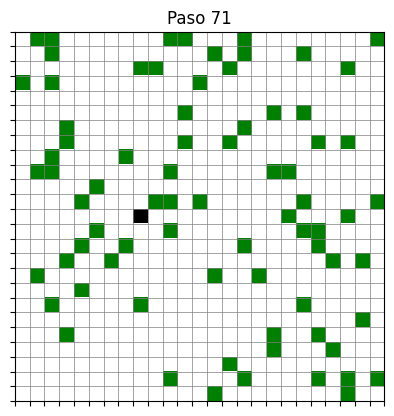

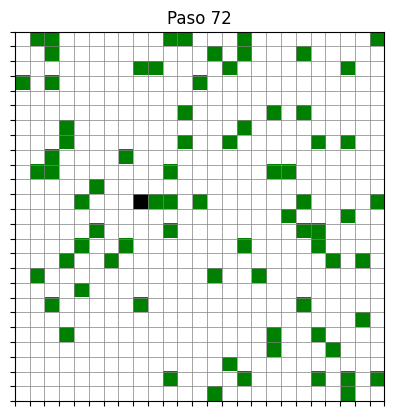

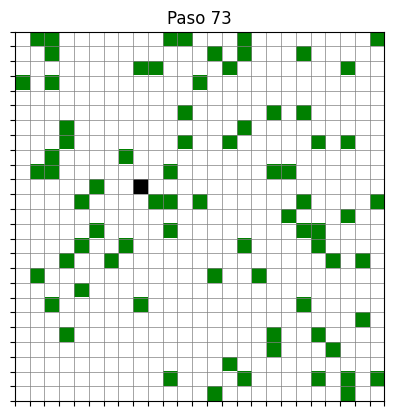

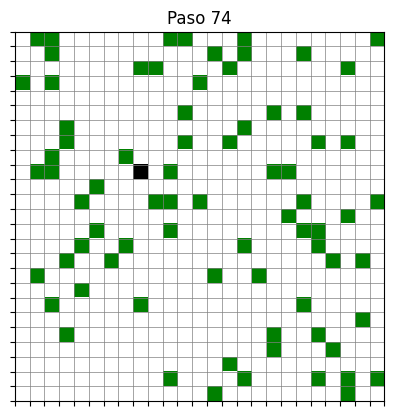

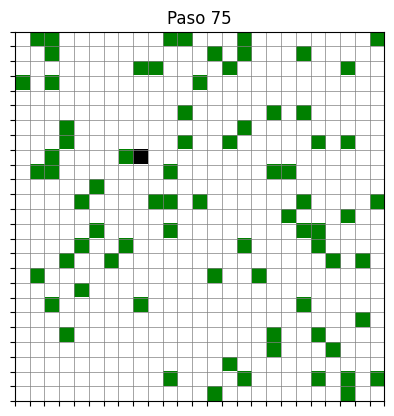

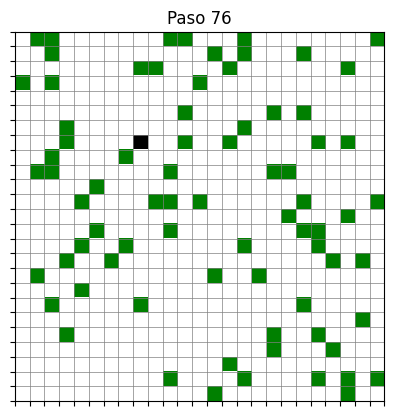

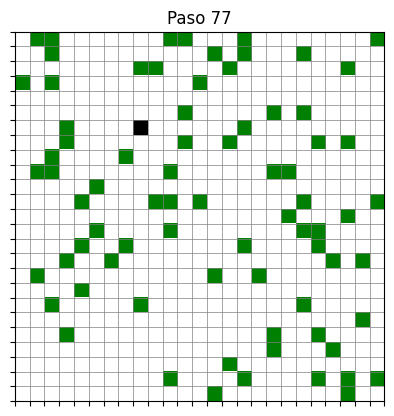

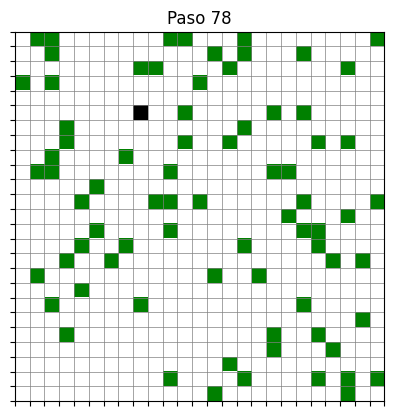

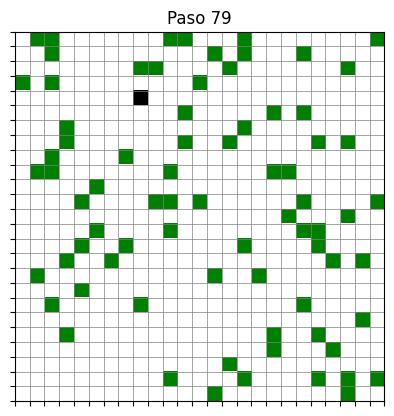

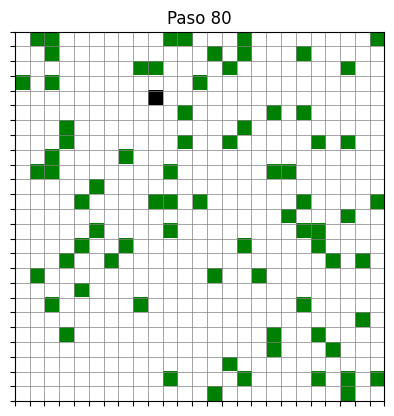

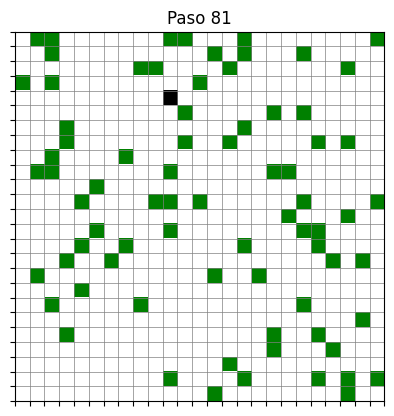

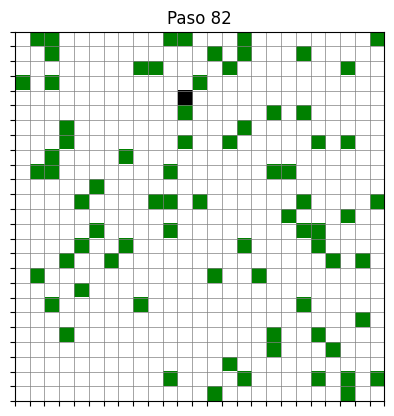

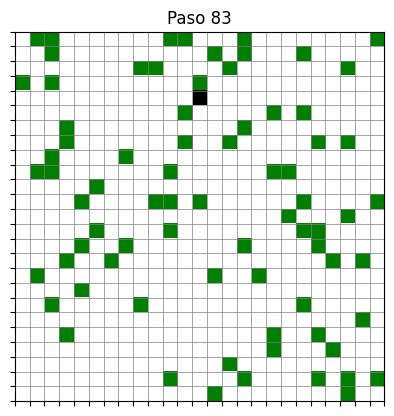

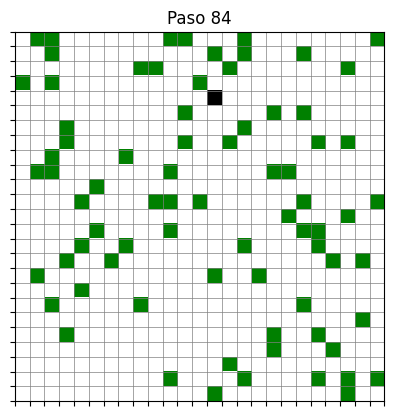

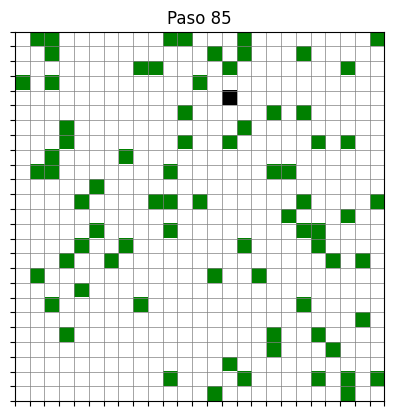

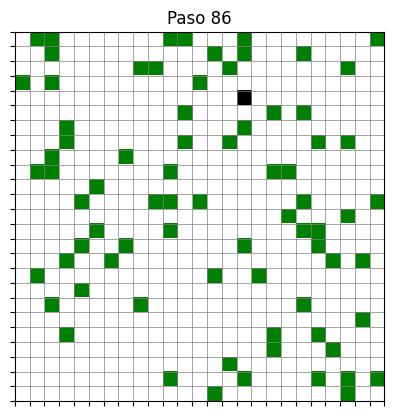

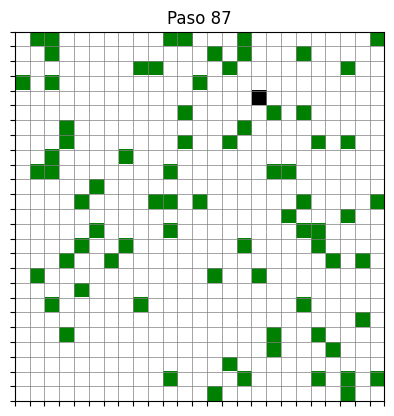

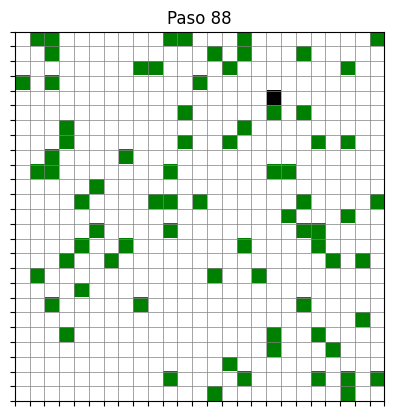

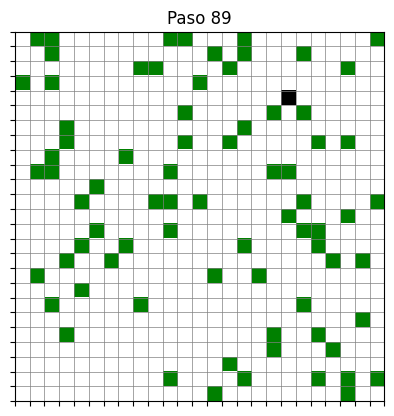

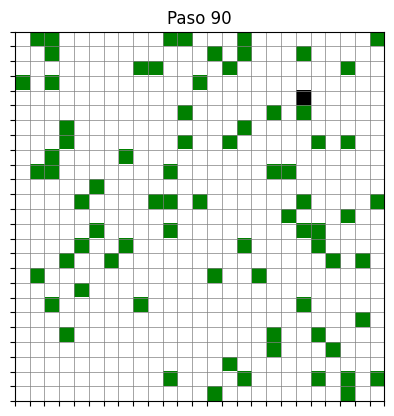

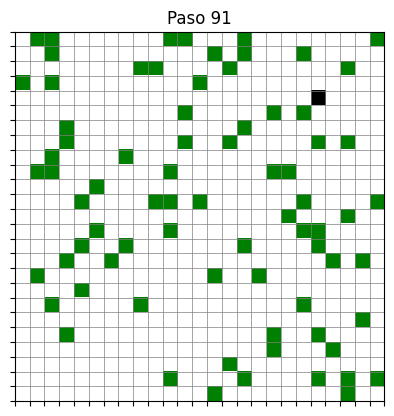

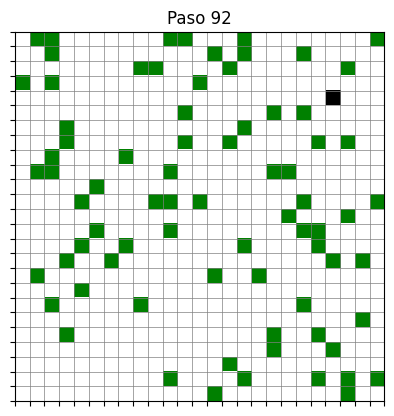

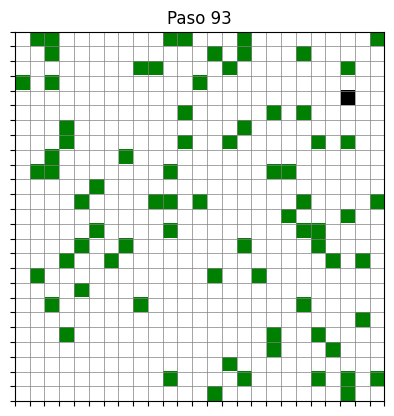

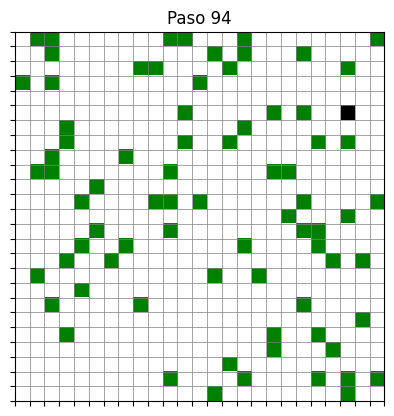

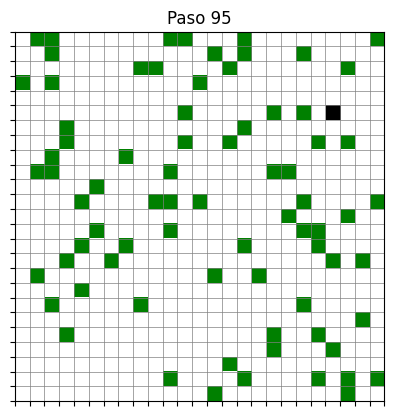

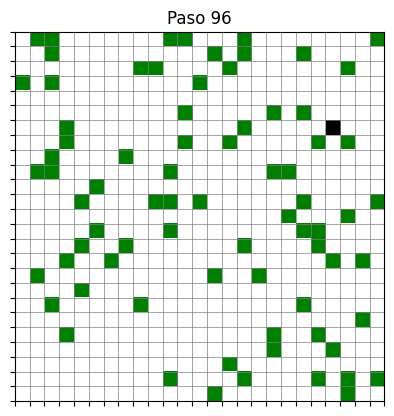

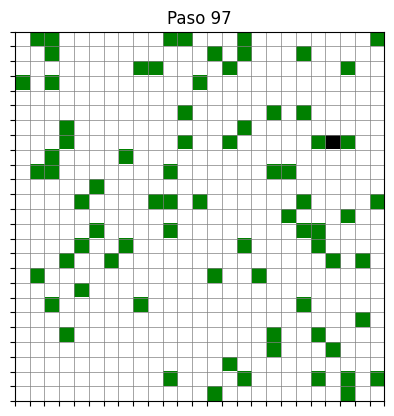

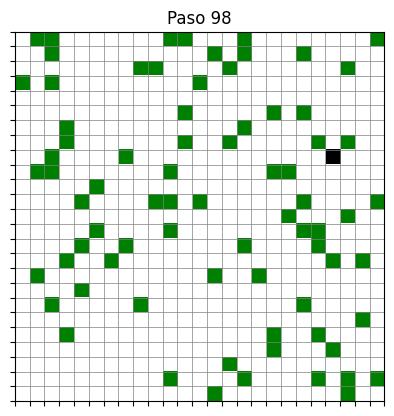

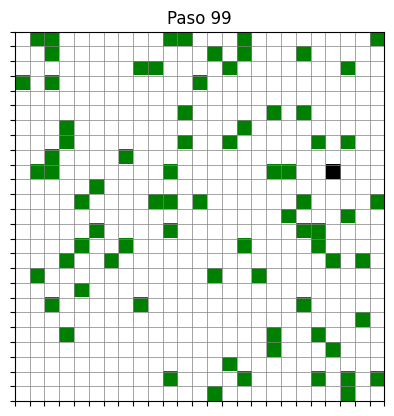

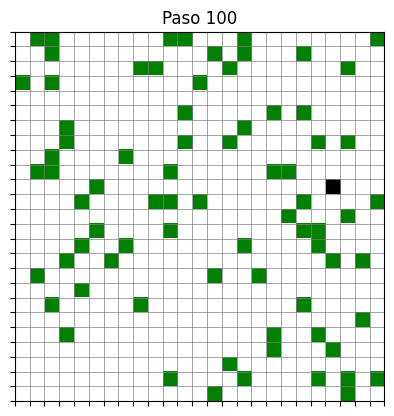

In [54]:
simular_robot()